# Fitness Prediction Benchmark Plots

Three benchmark visualizations: ncRNA, mRNA, and Protein DMS fitness prediction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import numpy as np
import os
from matplotlib import rcParams

# Load Arial font
font_path = '/storage9920/home/yanjie.huang/RNAVerse/notebooks/design/fonts/arial.ttf'
fm.fontManager.addfont(font_path)
rcParams['font.family'] = 'Arial'
rcParams['font.sans-serif'] = ['Arial']

# Force black text/axes/ticks
rcParams['text.color'] = 'black'
rcParams['axes.labelcolor'] = 'black'
rcParams['xtick.color'] = 'black'
rcParams['ytick.color'] = 'black'
rcParams['axes.edgecolor'] = 'black'

np.random.seed(42)

## 1. Zero-shot ncRNA Fitness Prediction
20 ncRNA datasets, 14 models.

Saved: figures/ncrna_performance_y04.svg


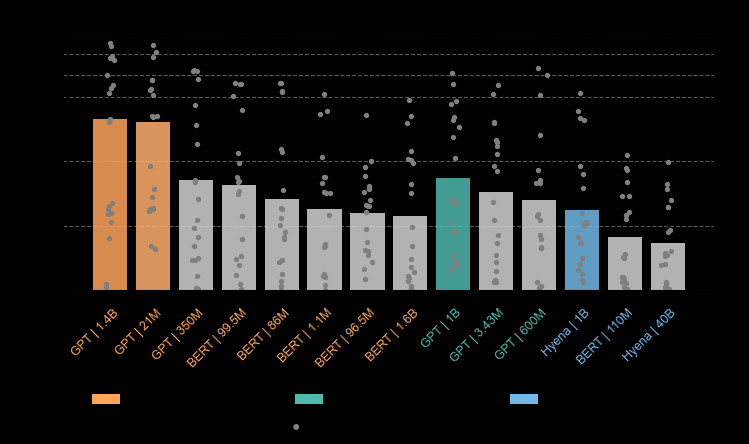

In [2]:
# === Paths ===
INPUT_CSV = 'data/rna_correlation.csv'
OUTPUT_DIR = 'figures'
OUTPUT_FILE = 'ncrna_performance_y04.svg'

# 20 ncRNA datasets
NCRNA_DATASETS = [
    'Andreasson_2020_ribozyme', 'Domingo_2018_tRNA',
    'Janzen_2022_fam21_ribozyme', 'Janzen_2022_fam22_ribozyme', 'Janzen_2022_fam31_ribozyme',
    'Kobori_2015_ribozyme_p4', 'Pitt_2010_ribozyme', 'Roberts_2023_hh_ribozyme',
    'Tome_2014_GFP_aptamer', 'Townshend_2015_4nt_aptamer',
    'Townshend_2015_5nt_aptamer', 'Townshend_2015_6nt_aptamer',
    'cata', 'clivia', 'myo', 'okra', 'pairwise_tRNA', 'pepper', 'tRNA_single', 'glms_obs'
]

# Model info (shared with mRNA cell below)
MODEL_INFO = {
    'rnafm_score': {'display_name': 'RNAFM', 'architecture': 'BERT', 'params': '99.5M', 'category': 'RNA Language Model'},
    'rnabert_score': {'display_name': 'RNABERT', 'architecture': 'BERT', 'params': '1.1M', 'category': 'RNA Language Model'},
    'rnamsm_score': {'display_name': 'RNAMSM', 'architecture': 'BERT', 'params': '96.5M', 'category': 'RNA Language Model'},
    'gena_score': {'display_name': 'GENA', 'architecture': 'BERT', 'params': '110M', 'category': 'DNA Language Model'},
    'aido_score': {'display_name': 'AIDO', 'architecture': 'BERT', 'params': '1.6B', 'category': 'RNA Language Model'},
    'generrna_score': {'display_name': 'GenerRNA', 'architecture': 'GPT', 'params': '350M', 'category': 'RNA Language Model'},
    'codongpt_score': {'display_name': 'codonGPT', 'architecture': 'GPT', 'params': '3.43M', 'category': 'Codon Language Model'},
    'ERNIE-RNA_checkpoint_score': {'display_name': 'ERNIE-RNA', 'architecture': 'BERT', 'params': '86M', 'category': 'RNA Language Model'},
    'codonfm_600m_score': {'display_name': 'CodonFM 600M', 'architecture': 'GPT', 'params': '600M', 'category': 'Codon Language Model'},
    'codonfm_1b_score': {'display_name': 'CodonFM 1B', 'architecture': 'GPT', 'params': '1B', 'category': 'Codon Language Model'},
    '30M_midtrain_ckpt86006_score': {'display_name': 'EVA 21M', 'architecture': 'GPT', 'params': '21M', 'category': 'RNA Language Model'},
    '1400M_mid_ckpt25500_score': {'display_name': 'EVA 1.4B', 'architecture': 'GPT', 'params': '1.4B', 'category': 'RNA Language Model'},
    'evo2_1b_score': {'display_name': 'Evo2 1B', 'architecture': 'Hyena', 'params': '1B', 'category': 'DNA Language Model'},
    'evo2_40b_score': {'display_name': 'Evo2 40B', 'architecture': 'Hyena', 'params': '40B', 'category': 'DNA Language Model'},
}

COLOR_GRADIENTS = {
    'RNA Language Model': ['#FFA45B', '#FFB87A', '#FFCA99', '#FFDCB8', '#FFEED7'],
    'Codon Language Model': ['#50B9AE', '#70C8BF', '#90D5CF', '#B0E2DF', '#D0EFED'],
    'DNA Language Model': ['#73B9E7', '#8FC7EC', '#ABD5F1', '#C7E3F6', '#E3F1FB'],
}
LEGEND_COLORS = {'RNA Language Model': '#FFA45B', 'Codon Language Model': '#50B9AE', 'DNA Language Model': '#73B9E7'}
CATEGORY_ORDER = {'RNA Language Model': 1, 'Codon Language Model': 2, 'DNA Language Model': 3}
RNAVERSE_MODELS = {'30M_midtrain_ckpt86006_score', '1400M_mid_ckpt25500_score'}
LIGHT_GRAY = '#D3D3D3'

def transform_y(y, max_actual):
    y = np.asarray(y)
    scale = 0.1 / (max_actual - 0.3)
    result = np.where(y <= 0.3, y, np.where(y <= max_actual, 0.3 + (y - 0.3) * scale, 0.4))
    return result if result.ndim > 0 else float(result)

def get_best_models_by_category(model_stats_df):
    best_models = {}
    for cat in ['RNA Language Model', 'Codon Language Model', 'DNA Language Model']:
        cat_df = model_stats_df[model_stats_df['Category'] == cat]
        if len(cat_df) > 0:
            best_models[cat] = cat_df.loc[cat_df['Mean'].idxmax(), 'Model']
    return best_models

def get_gradient_colors(n_models, color_gradient):
    if n_models == 0: return []
    if n_models == 1: return [color_gradient[len(color_gradient) // 2]]
    if n_models <= len(color_gradient): return color_gradient[:n_models]
    colors = []
    for i in range(n_models):
        position = i / (n_models - 1) * (len(color_gradient) - 1)
        idx = int(position)
        ratio = position - idx
        if idx >= len(color_gradient) - 1:
            colors.append(color_gradient[-1])
        else:
            start = mcolors.hex2color(color_gradient[idx])
            end = mcolors.hex2color(color_gradient[idx + 1])
            colors.append(mcolors.rgb2hex(tuple(s + (e - s) * ratio for s, e in zip(start, end))))
    return colors

def plot_rna_performance(datasets, output_file, title, min_fig_width=8):
    np.random.seed(42)
    df = pd.read_csv(INPUT_CSV)
    df_filtered = df[df['Dataset'].isin(datasets) & df['Model'].isin(MODEL_INFO.keys())].copy()
    df_filtered['Abs_Spearman'] = df_filtered['Spearman'].abs()

    model_stats, scatter_data = [], {}
    for model_name in MODEL_INFO:
        mdf = df_filtered[df_filtered['Model'] == model_name]
        if len(mdf) > 0:
            model_stats.append({'Model': model_name, 'Mean': mdf['Abs_Spearman'].mean(),
                                'Count': len(mdf), 'Category': MODEL_INFO[model_name]['category']})
            scatter_data[model_name] = mdf['Abs_Spearman'].values

    msdf = pd.DataFrame(model_stats)
    msdf['Category_Order'] = msdf['Category'].map(CATEGORY_ORDER)
    msdf = msdf.sort_values(['Category_Order', 'Mean'], ascending=[True, False]).reset_index(drop=True)

    x_models = msdf['Model'].tolist()
    y_means = msdf['Mean'].tolist()
    categories = msdf['Category'].tolist()
    all_values = np.concatenate(list(scatter_data.values()))
    max_actual = np.ceil(np.max(all_values) * 10) / 10

    # Gradient colors
    category_colors = {}
    for cat in ['RNA Language Model', 'Codon Language Model', 'DNA Language Model']:
        idxs = [i for i, c in enumerate(categories) if c == cat]
        if idxs:
            cols = get_gradient_colors(len(idxs), COLOR_GRADIENTS[cat])
            for j, mi in enumerate(idxs):
                category_colors[mi] = cols[j]
    original_colors = [category_colors[i] for i in range(len(x_models))]
    best_models = get_best_models_by_category(msdf)
    bar_colors = [original_colors[i] if m in RNAVERSE_MODELS or m in best_models.values() else LIGHT_GRAY
                  for i, m in enumerate(x_models)]

    n = len(x_models)
    fig, ax = plt.subplots(figsize=(max(min_fig_width, n * 0.6), 6))
    ax.bar(range(n), transform_y(y_means, max_actual), color=bar_colors, alpha=0.85, zorder=1, edgecolor='none')
    ax.set_ylim(0, 0.4)

    for i, model in enumerate(x_models):
        if model in scatter_data:
            xv = np.random.normal(i, 0.05, len(scatter_data[model]))
            ax.scatter(xv, transform_y(scatter_data[model], max_actual), color='#808080', s=8, alpha=1, zorder=2)

    ax.set_ylabel('|Spearman r|', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(range(n))
    ax.set_xticklabels([''] * n)

    for i, model in enumerate(x_models):
        info = MODEL_INFO[model]
        fw = 'semibold' if 'EVA' in info['display_name'] else 'normal'
        ax.text(i, -0.02, info['display_name'], transform=ax.get_xaxis_transform(),
                ha='right', va='top', fontsize=10, fontweight=fw, rotation=45)
        ax.text(i + 0.25, -0.065, f"{info['architecture']} | {info['params']}",
                transform=ax.get_xaxis_transform(), ha='right', va='top', fontsize=9,
                color=LEGEND_COLORS[info['category']], rotation=45)

    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray', zorder=0)
    ax.set_axisbelow(True)

    base_ticks = [0, 0.1, 0.2, 0.3]
    base_labels = ['0', '0.1', '0.2', '0.3']
    ct, cl = [], []
    val = 0.4
    while val <= max_actual:
        ct.append(float(transform_y(val, max_actual)))
        cl.append(f'{val:.1f}')
        val = round(val + 0.1, 1)
    ax.set_yticks(base_ticks + ct)
    ax.set_yticklabels(base_labels + cl)

    d = 0.008
    kw = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1)
    ax.plot((-d, +d), (0.75 - d, 0.75 + d), **kw)
    ax.plot((-d, +d), (0.75 - d - 0.01, 0.75 + d - 0.01), **kw)
    ax.tick_params(axis='y', labelsize=12)

    ax.text(1.015, 0.1, 'Better', transform=ax.transAxes, rotation=90, fontsize=12, color='black', ha='left', va='center')
    ax.annotate('', xy=(1.03, 1.0), xytext=(1.03, 0.2), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    handles = [plt.Rectangle((0,0),1,1, facecolor=LEGEND_COLORS[c], edgecolor='none')
               for c in ['RNA Language Model', 'Codon Language Model', 'DNA Language Model']]
    ax.legend(handles, ['RNA Language Model', 'Codon Language Model', 'DNA Language Model'],
              loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=10)
    ax.text(0.35, -0.53, "\u25cf", transform=ax.transAxes, fontsize=10, color='#808080', ha='left', va='center')
    ax.text(0.37, -0.53, "Individual Dataset", transform=ax.transAxes, fontsize=10, color='black', ha='left', va='center')
    plt.subplots_adjust(bottom=0.45, right=0.9)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out = os.path.join(OUTPUT_DIR, output_file)
    plt.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    print(f"Saved: {out}")
    plt.show()

# --- Run ---
plot_rna_performance(NCRNA_DATASETS, OUTPUT_FILE, 'Zero-shot ncRNA Fitness Prediction', min_fig_width=8)

## 2. Zero-shot mRNA Fitness Prediction
4 mRNA datasets, 14 models. Reuses MODEL_INFO, colors, and helpers from ncRNA cell above.

In [ ]:
# 4 mRNA datasets
MRNA_DATASETS = ['Gregory_2018_mRNA', 'Ke_2017_mRNA', 'Julien_2016_mRNA', 'newdataset']

plot_rna_performance(MRNA_DATASETS, 'mrna_performance_y05_new.svg', 'Zero-shot mRNA Fitness Prediction', min_fig_width=10)

## 3. Zero-shot Protein DMS Fitness Prediction
20 eukaryotic DMS datasets, 11 models. Break axis at 0.6, compresses to 0.6-0.85.

Saved: figures/fitness_prediction_merged_eukaryotic.svg


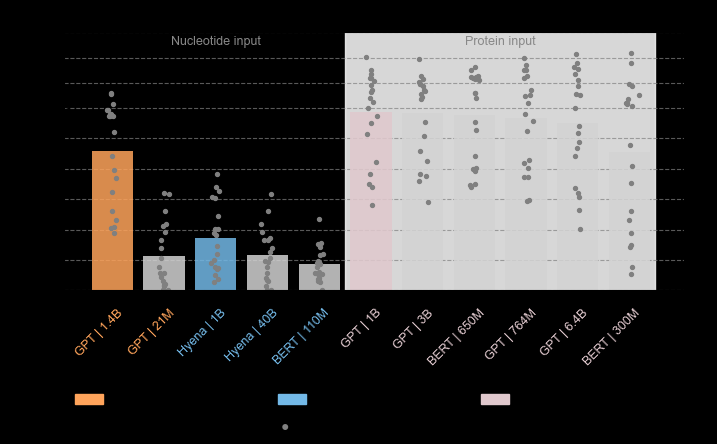

Saved summary: figures/summary_merged_eukaryotic.csv


In [4]:
# === Protein DMS (self-contained, different parameters) ===
DMS_CSV = 'data/protein_dms.csv'
DMS_OUTPUT_DIR = 'figures'

MODEL_METADATA = {
    'ProGen2 Large': {'category': 'PLM', 'architecture': 'GPT', 'params': '764M'},
    'ProGen2 XLarge': {'category': 'PLM', 'architecture': 'GPT', 'params': '6.4B'},
    'ProGen3 1B': {'category': 'PLM', 'architecture': 'GPT', 'params': '1B'},
    'ProGen3 3B': {'category': 'PLM', 'architecture': 'GPT', 'params': '3B'},
    'ESMC 300M': {'category': 'PLM', 'architecture': 'BERT', 'params': '300M'},
    'ESM1v': {'category': 'PLM', 'architecture': 'BERT', 'params': '650M'},
    'Evo2 1B': {'category': 'DLM', 'architecture': 'Hyena', 'params': '1B'},
    'Evo2 40B': {'category': 'DLM', 'architecture': 'Hyena', 'params': '40B'},
    'RNAGen 1.4B': {'category': 'RLM', 'architecture': 'GPT', 'params': '1.4B'},
    'RNAGen 30M': {'category': 'RLM', 'architecture': 'GPT', 'params': '21M'},
    'GENA': {'category': 'DLM', 'architecture': 'BERT', 'params': '110M'},
}
DISPLAY_NAME_MAP = {'RNAGen 1.4B': 'EVA 1.4B', 'RNAGen 30M': 'EVA 21M'}
CATEGORY_COLORS = {'PLM': '#E0C8CD', 'RLM': '#FFA45B', 'DLM': '#73B9E7'}
GRAY_COLOR = '#D3D3D3'

def process_model_data(df):
    model_data = {}
    for _, row in df.iterrows():
        name = row['Model']
        if pd.isna(name) or name == '':
            continue
        values = [float(row[c]) for c in df.columns[1:] if pd.notna(row[c])]
        if not values:
            continue
        meta = MODEL_METADATA.get(name, {'category': 'Unknown', 'architecture': '', 'params': ''})
        dname = DISPLAY_NAME_MAP.get(name, name)
        abs_vals = [abs(v) for v in values]
        model_data[dname] = {
            'mean': np.mean(abs_vals), 'individual_values': values,
            'category': meta['category'], 'architecture': meta['architecture'],
            'params': meta['params'], 'n_datasets': len(values)
        }
    return model_data

def plot_dms_chart(model_data, output_path, best_models_per_category=None):
    np.random.seed(42)
    DMS_CAT_ORDER = {'RLM': 0, 'DLM': 1, 'PLM': 2, 'Unknown': 3}
    sorted_models = sorted(model_data.items(), key=lambda x: (DMS_CAT_ORDER.get(x[1]['category'], 99), -x[1]['mean']))

    all_vals = []
    for _, d in sorted_models:
        all_vals.extend([abs(v) for v in d['individual_values']])
    max_actual = np.ceil(max(all_vals) * 10) / 10

    def dms_transform_y(y, ma):
        y = np.asarray(y)
        scale = 0.25 / (ma - 0.6)
        r = np.where(y <= 0.6, y, np.where(y <= ma, 0.6 + (y - 0.6) * scale, 0.85))
        return r if r.ndim > 0 else float(r)

    n = len(sorted_models)
    fig, ax = plt.subplots(figsize=(max(8, n * 0.6), 6))

    for i, (name, d) in enumerate(sorted_models):
        cat = d['category']
        use_color = False
        if name == 'EVA 21M':
            use_color = False
        elif best_models_per_category and name == best_models_per_category.get(cat):
            use_color = True
        color = CATEGORY_COLORS.get(cat, GRAY_COLOR) if use_color else GRAY_COLOR
        ax.bar(i, dms_transform_y(d['mean'], max_actual), color=color, alpha=0.85, zorder=1, edgecolor='none')
        if d['individual_values']:
            xj = np.random.normal(i, 0.05, len(d['individual_values']))
            yp = [abs(v) for v in d['individual_values']]
            ax.scatter(xj, dms_transform_y(yp, max_actual), color='#808080', s=8, alpha=1, zorder=2)

    # PLM background
    plm_idx = [i for i, (_, d) in enumerate(sorted_models) if d['category'] == 'PLM']
    if plm_idx:
        ax.axvspan(min(plm_idx) - 0.5, max(plm_idx) + 0.5, color='#F0F0F0', alpha=0.9, zorder=0)
        ax.text((min(plm_idx) + max(plm_idx)) / 2, 0.84, 'Protein input',
                ha='center', va='top', fontsize=9, color='#888888', style='italic')
    non_plm = [i for i, (_, d) in enumerate(sorted_models) if d['category'] != 'PLM']
    if non_plm:
        ax.text((min(non_plm) + max(non_plm)) / 2, 0.84, 'Nucleotide input',
                ha='center', va='top', fontsize=9, color='#888888', style='italic')

    ax.set_ylabel('|Spearman r|', fontsize=12)
    ax.set_title('Zero-shot Protein Fitness Prediction', fontsize=14)
    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([''] * n)

    for i, (name, d) in enumerate(sorted_models):
        fw = 'semibold' if 'EVA' in name else 'normal'
        ax.text(i, -0.02, name, transform=ax.get_xaxis_transform(),
                ha='right', va='top', fontsize=10, fontweight=fw, rotation=45)
        ax.text(i + 0.25, -0.065, f"{d['architecture']} | {d['params']}",
                transform=ax.get_xaxis_transform(), ha='right', va='top', fontsize=9,
                color=CATEGORY_COLORS.get(d['category'], '#808080'), rotation=45)

    ax.set_ylim(0, 0.85)
    bt = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    bl = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6']
    ct, cl = [], []
    v = 0.7
    while v <= max_actual:
        ct.append(float(dms_transform_y(v, max_actual)))
        cl.append(f'{v:.1f}')
        v = round(v + 0.1, 1)
    ax.set_yticks(bt + ct)
    ax.set_yticklabels(bl + cl)
    plt.yticks(fontsize=12)

    d = 0.008
    kw = dict(transform=ax.transAxes, color='k', clip_on=False, lw=1)
    ax.plot((-d, +d), (0.706 - d, 0.706 + d), **kw)
    ax.plot((-d, +d), (0.706 - d - 0.01, 0.706 + d - 0.01), **kw)

    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray', zorder=0)
    ax.set_axisbelow(True)
    ax.text(1.015, 0.1, 'Better', transform=ax.transAxes, rotation=90, fontsize=12, color='black', ha='left', va='center')
    ax.annotate('', xy=(1.03, 1.0), xytext=(1.03, 0.2), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    lc = [CATEGORY_COLORS['RLM'], CATEGORY_COLORS['DLM'], CATEGORY_COLORS['PLM']]
    ll = ['RNA Language Model', 'DNA Language Model', 'Protein Language Model']
    lh = [plt.Rectangle((0,0),1,1, color=c) for c in lc]
    ax.legend(lh, ll, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=10)
    ax.text(0.35, -0.53, "\u25cf", transform=ax.transAxes, fontsize=10, color='#808080', ha='left', va='center')
    ax.text(0.37, -0.53, "Individual Dataset", transform=ax.transAxes, fontsize=10, color='black', ha='left', va='center')
    plt.subplots_adjust(bottom=0.45, right=0.9)
    plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
    print(f"Saved: {output_path}")
    plt.show()

# --- Run ---
os.makedirs(DMS_OUTPUT_DIR, exist_ok=True)
df_dms = pd.read_csv(DMS_CSV)
model_data = process_model_data(df_dms)

best_models = {}
for cat in ['PLM', 'RLM', 'DLM']:
    cat_models = [(n, d['mean']) for n, d in model_data.items() if d['category'] == cat]
    if cat_models:
        best_models[cat] = max(cat_models, key=lambda x: x[1])[0]

plot_dms_chart(model_data, os.path.join(DMS_OUTPUT_DIR, 'fitness_prediction_merged_eukaryotic.svg'), best_models)

# Save summary CSV
summary_df = pd.DataFrame([
    {'Model': n, 'Mean_Abs_Spearman': d['mean'], 'N_Datasets': d['n_datasets'], 'Category': d['category']}
    for n, d in model_data.items()
]).sort_values('Mean_Abs_Spearman', ascending=False)
csv_out = os.path.join(DMS_OUTPUT_DIR, 'summary_merged_eukaryotic.csv')
summary_df.to_csv(csv_out, index=False)
print(f"Saved summary: {csv_out}")

## 4. Zero-shot Gene Essentiality Prediction
Gene essentiality prediction for bacteria and eukaryotes.

In [ ]:
# 4. Gene Essentiality Prediction
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 重置字体和颜色
font_path = '/storage9920/home/yanjie.huang/RNAVerse/notebooks/design/fonts/arial.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# 数据路径
INTERMEDIATE_DIR = Path("intermediate_data")
OUTPUT_DIR = Path("figures")

# 加载数据
bacteria_data = json.load(open(INTERMEDIATE_DIR / "bacteria_full_comparison_results.json"))
eukaryote_data = json.load(open(INTERMEDIATE_DIR / "eukaryote_gc_baseline_results.json"))

print(f"细菌数据: {bacteria_data['n_species']} 个物种")
print(f"真核数据: {eukaryote_data['n_species']} 个物种")

# 颜色配置
orange_color = (255/255, 164/255, 91/255)  # #FFA45B
blue_color = (115/255, 185/255, 231/255)   # #73B9E7
gray_color = (207/255, 208/255, 209/255)

# ============== 细菌图 ==============
bacteria_summary = bacteria_data['summary']
bacteria_results = bacteria_data['per_species']

model_data_bacteria = [
    ('Position\nBaseline', 'position', bacteria_summary['position_baseline']['mean'], gray_color),
    ('Evo2 1B', 'evo2_1b', bacteria_summary['evo2_1b']['mean'], blue_color),
    ('Evo2 7B', 'evo2_7b', bacteria_summary['evo2_7b']['mean'], blue_color),
    ('EVA 21M', 'rnagen_30m', bacteria_summary['rnagen_30m']['mean'], orange_color),
    ('EVA 1.4B', 'rnagen_1400m', bacteria_summary['rnagen_1400m']['mean'], orange_color),
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

y_positions = np.arange(len(model_data_bacteria))

# 绘制水平条形图
for i, (name, key, mean, color) in enumerate(model_data_bacteria):
    ax.barh(i, mean, height=0.75, color=color, alpha=0.8, edgecolor='black', linewidth=1.2)

# 添加散点图（各物种数据点）
np.random.seed(42)
for i, (name, key, mean, color) in enumerate(model_data_bacteria):
    values = [r[key] for r in bacteria_results]
    jitter = np.random.uniform(-0.2, 0.2, len(values))
    ax.scatter(values, i + jitter, c='black', alpha=0.4, s=15, zorder=5)

# 参考线
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

# 样式
ax.set_yticks(y_positions)
ax.set_yticklabels([m[0] for m in model_data_bacteria], fontsize=24)
ax.set_xlabel('AUROC', fontsize=26)
ax.set_title('Zero-shot Gene Essentiality Prediction (Bacteria)', fontsize=26)
ax.tick_params(axis='x', labelsize=20)
ax.set_xlim(0.4, 0.85)

# 边框
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('black')

# 网格
ax.grid(axis='x', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'fig7_essentiality_bacteria.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ 细菌基因本质性预测图已保存")

# ============== 真核图 ==============
eukaryote_summary = eukaryote_data['summary']
eukaryote_results = eukaryote_data['per_species']

model_data_eukaryote = [
    ('GC Content\nBaseline', 'gc_baseline', eukaryote_summary['gc_baseline']['mean'], gray_color),
    ('Evo2 1B', 'evo2_1b', eukaryote_summary['evo2_1b']['mean'], blue_color),
    ('Evo2 7B', 'evo2_7b', eukaryote_summary['evo2_7b']['mean'], blue_color),
    ('EVA 21M', 'rnagen_30m', eukaryote_summary['rnagen_30m']['mean'], orange_color),
    ('EVA 1.4B', 'rnagen_1400m', eukaryote_summary['rnagen_1400m']['mean'], orange_color),
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

y_positions = np.arange(len(model_data_eukaryote))

# 绘制水平条形图
for i, (name, key, mean, color) in enumerate(model_data_eukaryote):
    ax.barh(i, mean, height=0.75, color=color, alpha=0.8, edgecolor='black', linewidth=1.2)

# 添加散点图（各物种数据点）
np.random.seed(42)
for i, (name, key, mean, color) in enumerate(model_data_eukaryote):
    values = [r[key] for r in eukaryote_results if not np.isnan(r[key])]
    jitter = np.random.uniform(-0.2, 0.2, len(values))
    ax.scatter(values, i + jitter, c='black', alpha=0.4, s=15, zorder=5)

# 参考线
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)

# 样式
ax.set_yticks(y_positions)
ax.set_yticklabels([m[0] for m in model_data_eukaryote], fontsize=24)
ax.set_xlabel('AUROC', fontsize=26)
ax.set_title('Zero-shot Gene Essentiality Prediction (Eukaryote)', fontsize=26)
ax.tick_params(axis='x', labelsize=20)
ax.set_xlim(0.4, 0.7)

# 边框
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('black')

# 网格
ax.grid(axis='x', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_essentiality_eukaryote.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ 真核基因本质性预测图已保存")